# Detecting authentic vs. inauthentic DEI communication — weak supervision proof of concept

**Claim under test:** an instruction-tuned LLM can decompose a CEO interview into interpretable
*credibility signals*, and those noisy signals can be aggregated into an authenticity score
**without any labelled training data**.

### Pipeline

| Stage | What happens | Output |
|---|---|---|
| 1. Ingest | Read transcript, strip company/person identifiers | de-identified text |
| 2. Elicit | An instruction-tuned LLM answers 18 credibility questions, Yes / No / Unsure | vote matrix `L ∈ {+1, 0, −1}` |
| 3. Aggregate | Snorkel-style generative label model, fit by EM | authenticity score ∈ [0, 1] |

Elicitation runs on **Claude (`claude-opus-5`) via the Anthropic API**. Nothing in stages 1 or 3
depends on that choice — the label model consumes votes, not text — so the elicitor can be
swapped by changing `MODEL` in §0.

Stage 3 is the load-bearing part. We never tell the model which transcript is authentic.
The label model infers *how reliable each question is* from the agreement structure between
questions across documents, then weights them accordingly — the same trick Snorkel uses to
turn a pile of noisy labeling functions into a probabilistic label.

**De-identification.** The prompt receives only the transcript text. Company names, CEO names,
and third-party organisations are replaced with `[ORGANIZATION]` / `[NAME]` before the text is
sent, so the model cannot score a firm on its reputation instead of its words.

## 0. Setup

In [1]:
import importlib
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

sys.path.insert(0, str(Path.cwd() / "utils"))

# Pick up edits to utils/authenticity.py without restarting the kernel — Python
# caches imported modules, so a plain re-run of this cell would keep the old one.
import authenticity  # noqa: E402
importlib.reload(authenticity)

from authenticity import (  # noqa: E402
    DEFAULT_MODEL,
    MIN_DOCS_FOR_CORRELATION,
    N_SIGNALS,
    POLARITY,
    SIGNALS,
    SYSTEM_PROMPT,
    audit_leakage,
    build_user_prompt,
    build_vote_matrix,
    elicit_signals,
    fit_label_model,
    load_transcript,
)

POC_DIR = Path("data/poc")
CACHE_PATH = POC_DIR / "signal_cache.json"

# --- Claude API -----------------------------------------------------------
# Reads CLAUDE_API_KEY from the .env file in the project root, falling back to
# the SDK's own ANTHROPIC_API_KEY if that is what your environment sets.
load_dotenv()
CLAUDE_API_KEY = os.getenv("CLAUDE_API_KEY") or os.getenv("ANTHROPIC_API_KEY", "")
MODEL = DEFAULT_MODEL   # claude-opus-5

pd.set_option("display.max_colwidth", 90)
print(f"model: {MODEL}\nAPI key: {'found' if CLAUDE_API_KEY else 'MISSING — add CLAUDE_API_KEY to .env'}")

model: claude-opus-5
API key: found


### Chart palette

A validated diverging pair (blue ↔ red through a neutral grey) for signed quantities, and
neutral ink for chrome. Blue = evidence toward authentic, red = evidence against, grey = no
contribution. The pair passes CVD separation and contrast checks against the light surface.

In [2]:
PALETTE = {
    "authentic":  "#2a78d6",   # blue  — evidence toward authentic
    "inauthentic": "#e34948",  # red   — evidence against
    "neutral":    "#f0efec",   # grey  — diverging midpoint / abstention
    "surface":    "#fcfcfb",
    "ink":        "#0b0b0b",
    "ink_soft":   "#52514e",
    "muted":      "#898781",
    "grid":       "#e1e0d9",
}

DIVERGING = LinearSegmentedColormap.from_list(
    "authenticity", [PALETTE["inauthentic"], PALETTE["neutral"], PALETTE["authentic"]]
)

plt.rcParams.update({
    "figure.facecolor": PALETTE["surface"],
    "axes.facecolor": PALETTE["surface"],
    "axes.edgecolor": PALETTE["grid"],
    "axes.labelcolor": PALETTE["ink_soft"],
    "text.color": PALETTE["ink"],
    "xtick.color": PALETTE["muted"],
    "ytick.color": PALETTE["muted"],
    "font.family": "sans-serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 1. Ingest and de-identify

In [3]:
docs = [load_transcript(p) for p in sorted(POC_DIR.glob("*_transcript.json"))]

pd.DataFrame([
    {"doc_id": d["doc_id"], "company": d["company"], "CEO": d["ceo"],
     "year": d["year"], "words": d["n_words"],
     "leaked identifiers": audit_leakage(d["text"], d) or "— none —"}
    for d in docs
])

,doc_id,company,CEO,year,words,leaked identifiers
0,video_1_transcript,Netflix,Reed Hastings,2021,426,— none —
1,video_2_transcript,Walmart,Doug McMillon,2020,709,— none —
2,video_3_transcript,Johnson & Johnson,Alex Gorsky,2020,995,— none —


The `leaked identifiers` column is the safety check: it re-scans the *de-identified* text for
any token derived from the company or CEO name. It must read `— none —` for every row. Company
and CEO are held aside for our own reporting only; neither reaches the prompt.

In [4]:
# What the model actually sees.
print(docs[0]["text"][:700] + " ...")

INTERVIEWER: meantime i should also mention june [NAME] and his wife patty donated 120 million dollars to historically black colleges and later that month [ORGANIZATION] announced a move uh that it would move a hundred million dollars of its cash into black owned banks we talked a little bit about this uh on squawk box back then with one of [ORGANIZATION]'s employees but i asked [NAME] about what he thinks the role of corporations should be in all of this we talk so much about inequality and injustice and here's what he had to say

INTERVIEWEE: I think there's a broad duty to be thoughtful in the society in which you operate and so [ORGANIZATION] as an example uh also de made a deposit in bl ...


## 2. The 18 credibility signals

Each question is a **labeling function**: a cheap, noisy, individually-unreliable voter.
`polarity` records which answer counts as evidence *for* authenticity — 14 questions are
positively polarised, 4 negatively (prevention-focused framing, buzzwords without elaboration,
reactive timing, and — deliberately — external validation is positive while the vagueness and
risk-avoidance items are negative).

Polarity is not a scoring weight. It only anchors the label model's latent class so that
"class 0" reliably means *authentic*; EM on its own is sign-symmetric and would otherwise be
free to converge to the mirror-image solution. **How much** each question counts is learned.

In [5]:
signals_df = pd.DataFrame([
    {"#": s.id, "dimension": s.dimension,
     "polarity": "+ authentic" if s.polarity > 0 else "− inauthentic",
     "question": s.question}
    for s in SIGNALS
]).set_index("#")
signals_df

,dimension,polarity,question
#,,,
1,personal investment,+ authentic,Does the CEO reference personal experiences when discussing DEI?
2,personal investment,+ authentic,"Does the CEO explain why DEI matters to them individually, beyond business rationale?"
3,personal investment,+ authentic,Does the CEO acknowledge their own biases or blind spots?
4,personal investment,+ authentic,Does the CEO frame DEI as a core personal value rather than a corporate initiative?
5,personal investment,+ authentic,"Does the CEO use first-person language (""I believe,"" ""I've committed to"") rather than ..."
6,consistency,+ authentic,Has the CEO discussed DEI consistently across multiple time periods or occasions?
7,candor,+ authentic,Does the CEO acknowledge the company's current shortcomings or past failures on DEI?
8,candor,+ authentic,"Does the CEO discuss pushback, criticism, or internal disagreement about DEI efforts?"
9,candor,+ authentic,Does the CEO cite specific feedback from employees or affected groups?


## 3. Signal elicitation with Claude

One call per transcript returns all 18 answers plus a short verbatim quote for each. The quote
is what makes a score auditable — every vote can be traced back to a line of the transcript.

Three design choices worth stating:

- **Structured outputs.** `messages.parse` with a Pydantic schema (`SignalReport`) constrains the
  reply at decode time, so every `answer` is literally `yes` / `no` / `unsure` and malformed JSON
  is not a failure mode. What the schema does *not* guarantee is **completeness** — that all 18
  signals appear exactly once — so that is still validated in `normalize_report`, and a short
  reply is retried with the specific gap fed back to the model.
- **Adaptive thinking at high effort.** These questions require weighing whole-transcript
  evidence ("is this reactive?", "is the framing promotion- or prevention-focused?"), which is
  reasoning work, not extraction. The elicitation quality is the ceiling on everything
  downstream — the label model can average out a *noisy* signal but cannot repair a
  *systematically biased* one.
- **Asking all 18 in one call** is cheaper and gives the model whole-transcript context, but it
  induces correlation between answers — the model reasons about them jointly. That is precisely
  the failure mode the label model's redundancy weighting is built to absorb (§5); with a larger
  corpus you may prefer one call per signal to buy stronger conditional independence.

Responses are cached to disk, so re-running the notebook does not re-bill the API.

In [6]:
# The instruction that goes to the model, and the per-transcript question list.
print(SYSTEM_PROMPT)
print("\n" + "─" * 78 + "\n")
print(build_user_prompt("[transcript text]")[:520] + " ...")

You are a careful discourse analyst assessing how an executive talks about diversity, equity, and inclusion in an interview transcript.

You answer a fixed list of yes/no questions about the INTERVIEWEE only. Ignore the interviewer except as context for what the interviewee is responding to.

Rules:
- Every answer must be exactly "yes", "no", or "unsure".
- Answer "yes" only when the transcript contains direct evidence. Do not infer from what a speaker in this position would plausibly believe.
- Answer "unsure" when the transcript is genuinely ambiguous or the topic never comes up in enough detail to judge. "unsure" is a real answer, not a hedge - use it rather than guessing.
- Judge only what is present in this excerpt. Do not use outside knowledge about the speaker or their organisation, and do not speculate about sincerity beyond the text.
- For each "yes", quote the specific words that justify it. Use an empty string for "no" and "unsure".

Answer all 18 questions, exactly once eac

In [7]:
import anthropic  # noqa: E402


def run_elicitation(docs, cache_path=CACHE_PATH, force=False) -> dict:
    """Elicit signals for every document, reusing cached responses where possible."""
    cache = json.loads(cache_path.read_text()) if cache_path.exists() and not force else {}
    todo = [d for d in docs if d["doc_id"] not in cache]

    if todo:
        if not CLAUDE_API_KEY:
            raise RuntimeError(
                f"{len(todo)} transcript(s) not cached and no API key is set. "
                "Add CLAUDE_API_KEY=sk-ant-... to the .env file in the project root "
                "and re-run."
            )
        client = anthropic.Anthropic(api_key=CLAUDE_API_KEY)
        for d in todo:
            print(f"eliciting {d['doc_id']} ...", end=" ", flush=True)
            result = elicit_signals(d["text"], client, model=MODEL)
            cache[d["doc_id"]] = result
            note = "" if result["attempts"] == 1 else f", {result['attempts']} attempts"
            print(f"{result['usage']['output']} output tokens{note}")
        cache_path.write_text(json.dumps(cache, indent=2))

    return cache


signal_cache = run_elicitation(docs)
print(f"\n{len(signal_cache)} transcript(s) with elicited signals.")

eliciting video_1_transcript ... 507 output tokens
eliciting video_2_transcript ... 598 output tokens
eliciting video_3_transcript ... 860 output tokens

3 transcript(s) with elicited signals.


### The vote matrix

In [8]:
# Rows = documents, columns = signals, values in {+1 yes, 0 unsure, -1 no}.
L = build_vote_matrix(docs, signal_cache)
labels = [f"{d['company']} ({d['year']})" for d in docs]

votes_df = pd.DataFrame(
    np.where(L == 1, "yes", np.where(L == -1, "no", "unsure")),
    index=labels, columns=[f"S{s.id}" for s in SIGNALS],
)
print(f"vote matrix: {L.shape[0]} documents x {L.shape[1]} signals")
print(f"abstention rate: {(L == 0).mean():.0%}")
votes_df.T

vote matrix: 3 documents x 18 signals
abstention rate: 13%


,Netflix (2021),Walmart (2020),Johnson & Johnson (2020)
S1,no,no,yes
S2,no,no,yes
S3,no,no,yes
S4,no,no,unsure
S5,no,yes,yes
S6,unsure,unsure,yes
S7,unsure,yes,no
S8,no,no,no
S9,no,no,yes
S10,yes,yes,yes


## 4. The generative label model

The aggregation step. Given only the vote matrix — no ground truth — the model treats each
document's authenticity as a latent binary variable $y$ and each question $j$ as a noisy
channel with its own emission distribution:

$$\theta_{j,c,v} = P(\text{question } j \text{ votes } v \mid y = c), \qquad v \in \{\text{yes, unsure, no}\}$$

EM alternates between inferring $P(y \mid \text{votes})$ for each document and re-estimating
every $\theta_j$ from those soft assignments. Questions whose votes track the emerging consensus
earn sharp emission distributions and therefore large log-odds per vote; questions that vote
near-randomly flatten out and are effectively ignored. A Dirichlet prior keyed on each question's
polarity keeps the problem well-posed when there are few documents, and pins "class 0" to
*authentic* so the fitted model is orientation-stable.

The final score is a sigmoid over the summed log-odds, divided by $\sqrt{\text{effective votes}}$.
Without that temperature term 18 votes pile up enough log-odds to saturate every document to
0.000 or 1.000; the division spreads the scores across $[0, 1]$ while preserving the ranking
exactly (Spearman ≈ 1.0 against the raw posterior).

In [9]:
model = fit_label_model(L)

print(f"EM converged in {model.n_iter_} iterations "
      f"(log-likelihood {model.log_likelihood_:.2f})")
print(f"correlation weighting: "
      f"{'on' if model.correlations_ is not None else f'off — needs ≥ {MIN_DOCS_FOR_CORRELATION} documents'}")

scores = model.score(L)
contributions = model.contributions(L)

results = pd.DataFrame({
    "company": [d["company"] for d in docs],
    "CEO": [d["ceo"] for d in docs],
    "year": [d["year"] for d in docs],
    "yes": (L == 1).sum(axis=1),
    "unsure": (L == 0).sum(axis=1),
    "no": (L == -1).sum(axis=1),
    "log-odds": model.log_odds(L).round(2),
    "authenticity score": scores.round(3),
    "label": np.where(model.predict(L) > 0, "authentic", "inauthentic"),
}).sort_values("authenticity score", ascending=False)
results

EM converged in 5 iterations (log-likelihood -42.79)
correlation weighting: off — needs ≥ 30 documents


,company,CEO,year,yes,unsure,no,log-odds,authenticity score,label
2,Johnson & Johnson,Alex Gorsky,2020,11,1,6,9.97,0.918,authentic
1,Walmart,Doug McMillon,2020,5,2,11,-9.43,0.087,inauthentic
0,Netflix,Reed Hastings,2021,3,4,11,-10.84,0.052,inauthentic


## 5. Which signals moved each score

The score decomposes additively in log-odds space, so every document's result can be read back
as a per-question ledger. This is the practical argument for weak supervision over a black-box
classifier: the output is not just a number but an auditable account of which observable
features of the language produced it.

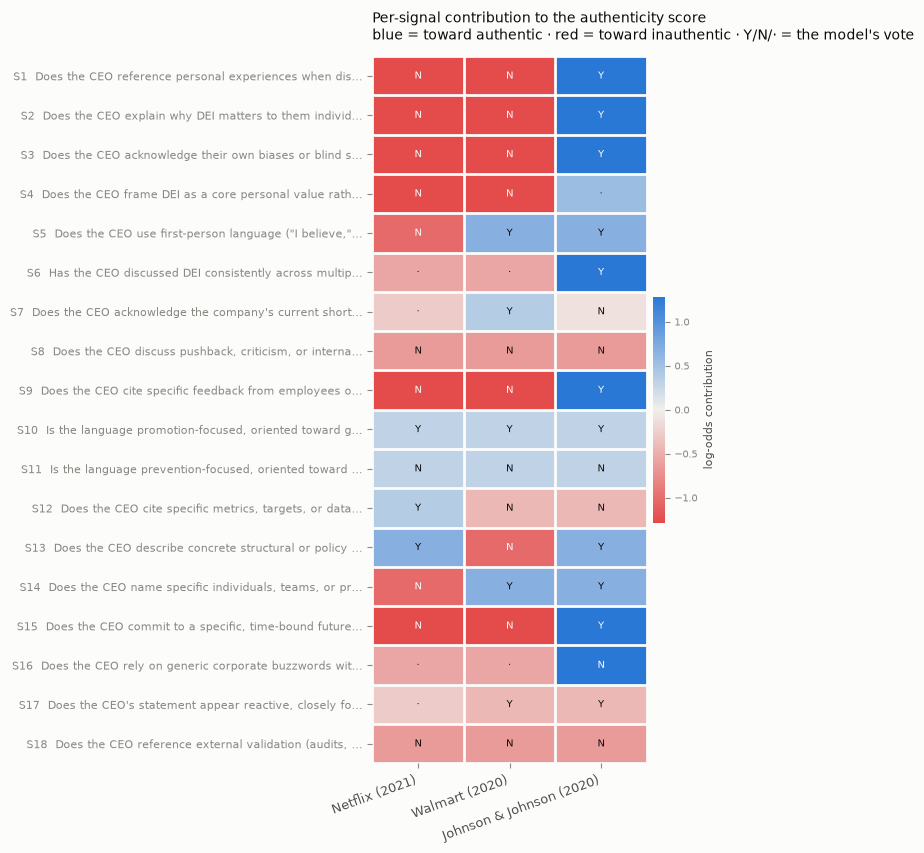

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 8.6))

vmax = float(np.abs(contributions).max()) or 1.0
im = ax.imshow(contributions.T, cmap=DIVERGING,
               norm=TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax), aspect="auto")

ax.set_xticks(range(len(docs)))
ax.set_xticklabels(labels, rotation=20, ha="right", color=PALETTE["ink_soft"])
ax.set_yticks(range(N_SIGNALS))
ax.set_yticklabels(
    [f"S{s.id}  {s.question[:52]}{'…' if len(s.question) > 52 else ''}" for s in SIGNALS],
    fontsize=8,
)

# 2px surface gap between cells
ax.set_xticks(np.arange(-.5, len(docs), 1), minor=True)
ax.set_yticks(np.arange(-.5, N_SIGNALS, 1), minor=True)
ax.grid(which="minor", color=PALETTE["surface"], linewidth=2)
ax.tick_params(which="minor", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# annotate the vote itself, so colour is never the only channel
for i in range(len(docs)):
    for j in range(N_SIGNALS):
        mark = {1: "Y", 0: "·", -1: "N"}[L[i, j]]
        ax.text(i, j, mark, ha="center", va="center", fontsize=7.5,
                color=PALETTE["ink"] if abs(contributions[i, j]) < vmax * 0.55 else PALETTE["surface"])

cbar = fig.colorbar(im, ax=ax, shrink=0.32, pad=0.02)
cbar.set_label("log-odds contribution", color=PALETTE["ink_soft"], fontsize=8)
cbar.outline.set_visible(False)
cbar.ax.tick_params(colors=PALETTE["muted"], labelsize=7)

ax.set_title("Per-signal contribution to the authenticity score\n"
             "blue = toward authentic · red = toward inauthentic · Y/N/· = the model's vote",
             fontsize=10, color=PALETTE["ink"], pad=12, loc="left")
plt.tight_layout()
plt.show()

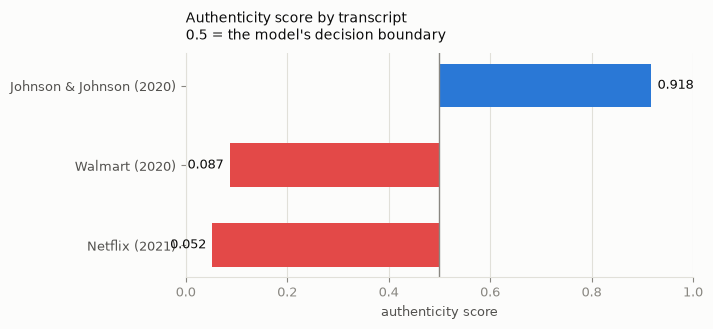

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 0.62 * len(docs) + 1.5))

order = np.argsort(scores)
y = np.arange(len(docs))
colors = [PALETTE["authentic"] if scores[i] > 0.5 else PALETTE["inauthentic"] for i in order]

ax.barh(y, scores[order] - 0.5, left=0.5, color=colors, height=0.55)
ax.axvline(0.5, color=PALETTE["muted"], linewidth=1)

for yi, i in enumerate(order):
    ha = "left" if scores[i] > 0.5 else "right"
    offset = 0.012 if scores[i] > 0.5 else -0.012
    ax.text(scores[i] + offset, yi, f"{scores[i]:.3f}", va="center", ha=ha,
            fontsize=9, color=PALETTE["ink"])

ax.set_yticks(y)
ax.set_yticklabels([labels[i] for i in order], color=PALETTE["ink_soft"])
ax.set_xlim(0, 1)
ax.set_xlabel("authenticity score")
ax.set_title("Authenticity score by transcript\n0.5 = the model's decision boundary",
             fontsize=10, color=PALETTE["ink"], pad=10, loc="left")
ax.grid(axis="x", color=PALETTE["grid"], linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [12]:
# The evidence ledger for the top-scoring transcript.
top = int(np.argmax(scores))
entry = signal_cache[docs[top]["doc_id"]]
ev = entry["evidence"]

rows = []
for k, s in enumerate(SIGNALS):
    quote = ev.get(str(s.id), ev.get(s.id, "")) or ""
    rows.append({
        "signal": f"S{s.id}",
        "question": s.question[:60] + ("…" if len(s.question) > 60 else ""),
        "vote": {1: "yes", 0: "unsure", -1: "no"}[L[top, k]],
        "contribution": round(float(contributions[top, k]), 3),
        "evidence": (quote[:80] + "…") if len(quote) > 80 else quote,
    })

print(f"{docs[top]['company']} — {docs[top]['ceo']} ({docs[top]['year']}), "
      f"score {scores[top]:.3f}\n")
pd.DataFrame(rows).sort_values("contribution", ascending=False).head(10).set_index("signal")

Johnson & Johnson — Alex Gorsky (2020), score 0.918



,question,vote,contribution,evidence
signal,,,,
S1,Does the CEO reference personal experiences when discussing …,yes,1.286,I know you know for me personally ... having you know been in my role over eight…
S3,Does the CEO acknowledge their own biases or blind spots?,yes,1.286,in in making sure in many cases particularly somebody like me as a white male th…
S6,Has the CEO discussed DEI consistently across multiple time …,yes,1.286,while we've been having discussions for decade about diversity and inclusion
S16,Does the CEO rely on generic corporate buzzwords without ela…,no,1.286,
S15,"Does the CEO commit to a specific, time-bound future action?",yes,1.286,we're to be doing more than 10 million dollars over the next three years
S9,Does the CEO cite specific feedback from employees or affect…,yes,1.286,on the phone over the weekend with employees and to hear some of their stories e…
S2,"Does the CEO explain why DEI matters to them individually, b…",yes,1.286,telling stories about you know frankly being concerned over the last few weeks w…
S13,Does the CEO describe concrete structural or policy changes …,yes,0.680,it starts by having all of our leaders to a credo dialogue ... we're working wit…
S5,"Does the CEO use first-person language (""I believe,"" ""I've c…",yes,0.680,I know you know for me personally ... I tried to be as connected as I could with…


## 6. What the label model learned about each question

In [13]:
learned = pd.DataFrame({
    "signal": [f"S{s.id}" for s in SIGNALS],
    "dimension": [s.dimension for s in SIGNALS],
    "polarity": ["+" if s.polarity > 0 else "−" for s in SIGNALS],
    "learned reliability": model.learned_accuracy().round(3),
    "weight": model.weights_.round(3),
    "abstention rate": (L == 0).mean(axis=0).round(2),
}).set_index("signal")

if model.correlations_ is None:
    print(f"NOTE: with {L.shape[0]} documents, reliabilities stay near the prior — there is not "
          f"enough\ndisagreement between questions to estimate them. This column becomes "
          f"informative at\nroughly {MIN_DOCS_FOR_CORRELATION}+ documents, which is the point of §7.")
learned

NOTE: with 3 documents, reliabilities stay near the prior — there is not enough
disagreement between questions to estimate them. This column becomes informative at
roughly 30+ documents, which is the point of §7.


,dimension,polarity,learned reliability,weight,abstention rate
signal,,,,,
S1,personal investment,+,0.76,1.0,0.00
S2,personal investment,+,0.76,1.0,0.00
S3,personal investment,+,0.76,1.0,0.00
S4,personal investment,+,0.70,1.0,0.33
S5,personal investment,+,0.76,1.0,0.00
S6,consistency,+,0.76,1.0,0.67
S7,candor,+,0.56,1.0,0.33
S8,candor,+,0.56,1.0,0.00
S9,candor,+,0.76,1.0,0.00


## 7. Does the aggregation actually work? A recovery experiment

With three documents we cannot validate the label model on real data — there is no ground truth
and no statistical power. So we validate the *machinery* on synthetic corpora where the true
labels are known by construction: simulate questions with known reliabilities, including a
deliberately redundant block of three near-duplicate questions, and check that the model
recovers the labels and the reliabilities.

This is the honest way to make the claim at this scale: the PoC demonstrates that the pipeline
is sound and produces auditable scores, and the simulation shows *at what corpus size* the
aggregation step starts earning its keep. The baseline is a plain polarity-weighted vote count —
every question counted equally — which is exactly what the label model has to beat to justify
itself.

In [14]:
def simulate(n_docs, seed, n_redundant=3):
    """Corpus with known labels, heterogeneous question reliability, and a redundant block."""
    rng = np.random.default_rng(seed)
    y = rng.choice([1, -1], size=n_docs)

    # questions 0-5 strong, 6-11 moderate, 12-17 near-random
    reliability = np.r_[np.full(6, 0.82), np.full(6, 0.66), np.full(6, 0.54)]
    abstain = np.r_[np.full(6, 0.10), np.full(6, 0.18), np.full(6, 0.30)]

    L = np.zeros((n_docs, N_SIGNALS), dtype=int)
    for j in range(N_SIGNALS):
        for i in range(n_docs):
            p_yes = reliability[j] if y[i] == 1 else 1 - reliability[j]
            if POLARITY[j] < 0:
                p_yes = 1 - p_yes
            probs = [p_yes * (1 - abstain[j]), abstain[j], (1 - p_yes) * (1 - abstain[j])]
            L[i, j] = rng.choice([1, 0, -1], p=probs)

    # redundant block: questions 4 and 5 are noisy copies of question 3
    for j in range(3, 3 + n_redundant - 1):
        L[:, j + 1] = np.where(rng.random(n_docs) < 0.08, -L[:, 3], L[:, 3])

    return L, y, reliability


N_REPS = 200   # enough that the differences below are larger than their standard error

rows = []
for n in [3, 10, 30, 100, 300, 600]:
    acc_lm, acc_vote = [], []
    for rep in range(N_REPS):
        Ls, ys, _ = simulate(n, seed=1000 + rep)
        acc_lm.append((fit_label_model(Ls).predict(Ls) == ys).mean())
        naive = np.where((Ls * POLARITY).sum(axis=1) >= 0, 1, -1)   # unweighted baseline
        acc_vote.append((naive == ys).mean())

    lm, vote = np.array(acc_lm), np.array(acc_vote)
    delta = lm - vote
    rows.append({
        "documents": n,
        "polarity vote (baseline)": round(float(vote.mean()), 3),
        "label model": round(float(lm.mean()), 3),
        "gain": f"{delta.mean():+.3f} ± {delta.std() / np.sqrt(N_REPS):.3f}",
        "correlation weighting": "on" if n >= MIN_DOCS_FOR_CORRELATION else "off",
    })

recovery = pd.DataFrame(rows).set_index("documents")
recovery

,polarity vote (baseline),label model,gain,correlation weighting
documents,,,,
3,0.902,0.905,+0.003 ± 0.008,off
10,0.906,0.889,-0.017 ± 0.005,off
30,0.900,0.889,-0.011 ± 0.004,on
100,0.900,0.907,+0.007 ± 0.002,on
300,0.900,0.921,+0.021 ± 0.001,on
600,0.902,0.926,+0.024 ± 0.001,on


redundant block (questions 4-6) mean weight: 0.45
all other questions        mean weight: 0.93


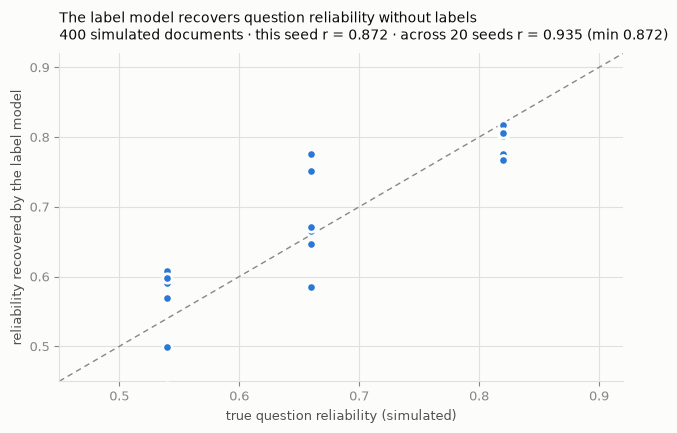

In [15]:
# Does the model recover which questions are reliable? (needs a real corpus size)
Ls, ys, true_reliability = simulate(400, seed=7)
big = fit_label_model(Ls)
recovered = big.learned_accuracy()

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.scatter(true_reliability, recovered, s=46, color=PALETTE["authentic"],
           edgecolor=PALETTE["surface"], linewidth=2, zorder=3)
lims = [0.45, 0.92]
ax.plot(lims, lims, color=PALETTE["muted"], linewidth=1, linestyle=(0, (4, 3)), zorder=1)
ax.set_xlim(*lims)
ax.set_ylim(*lims)
ax.set_xlabel("true question reliability (simulated)")
ax.set_ylabel("reliability recovered by the label model")
ax.grid(color=PALETTE["grid"], linewidth=0.8)
ax.set_axisbelow(True)

r = float(np.corrcoef(true_reliability, recovered)[0, 1])

# One seed can flatter or understate; report the spread across seeds too.
r_all = []
for s in range(20):
    Lr, _, tr = simulate(400, seed=s)
    r_all.append(float(np.corrcoef(tr, fit_label_model(Lr).learned_accuracy())[0, 1]))

ax.set_title(f"The label model recovers question reliability without labels\n"
             f"400 simulated documents · this seed r = {r:.3f} · "
             f"across 20 seeds r = {np.mean(r_all):.3f} (min {np.min(r_all):.3f})",
             fontsize=10, color=PALETTE["ink"], pad=10, loc="left")

w = big.weights_
print(f"redundant block (questions 4-6) mean weight: {w[3:6].mean():.2f}")
print(f"all other questions        mean weight: {np.delete(w, [3, 4, 5]).mean():.2f}")
plt.tight_layout()
plt.show()

Two results from the table and the plot above, and one caveat.

**The label model needs a corpus to pay off.** Below ~100 documents it matches the plain vote
count or is slightly worse — with little data, EM's estimated reliabilities are noisier than
just counting votes equally. The gain becomes real at 300+ documents (+0.021 ± 0.001) and keeps
growing. **At n = 3 the label model is not buying accuracy over a vote count; what it buys is
the calibrated score and the per-signal decomposition.** The accuracy argument only arrives at
corpus scale.

**Reliability is recovered without labels** (r ≈ 0.94 across seeds), and the redundant block of
three near-duplicate questions is correctly discounted to roughly half the weight of the others
— so a cluster of questions that all measure the same thing cannot outvote the rest.

**Caveat on the simulation.** It generates votes that are conditionally independent given the
true label, which is the label model's own assumption. Real LLM answers — all 18 elicited in one
call — are more correlated than this, so these numbers are an optimistic bound on the crossover
point, not a prediction of it.

## 8. Reading the results — and what this PoC does not show

**What is demonstrated.** The pipeline runs end to end: a de-identified transcript in, an
auditable authenticity score out, with no labelled training data anywhere. Every score
decomposes into per-question log-odds, each traceable to a quote. The simulation shows the
aggregation step recovers question reliability without labels (r ≈ 0.94) and discounts a
redundant block of questions that a plain vote count would let dominate.

**What is not.** Three documents is a demonstration, not an evaluation:

- **No ground truth.** Nothing here establishes that the scores are *correct*, only that they
  are produced coherently and can be inspected. Validating that requires human-coded labels on
  a held-out sample — the natural next step.
- **At this size the label model is not yet earning its accuracy.** §7 measures it: below ~100
  documents it matches a plain polarity-weighted vote count, and the gain only becomes clear at
  300+. At n = 3, EM has too little disagreement to estimate reliabilities and they stay pinned
  near their prior, so the score is driven mostly by the polarity structure. What the label
  model contributes *here* is the calibrated continuous score and the per-signal ledger — the
  accuracy case is a claim about the full corpus, and it is not yet demonstrated on real data.
- **Questions are answered jointly.** One call per transcript means the 18 answers are not
  conditionally independent, violating an assumption the label model makes. Redundancy weighting
  absorbs some of this; per-signal calls would absorb more, at 18× the cost.
- **The scores inherit the elicitor's judgment.** Structured outputs guarantee the *shape* of
  each answer, never its correctness. If Claude systematically reads, say, hedged corporate
  register as candor, every score shifts together and the label model cannot detect it — EM sees
  only agreement between questions, not truth. Watch the `attempts` column as a health check,
  and re-run a sample under a different elicitor before treating any score as a property of the
  transcript rather than of the model reading it.
- **The construct is contestable.** These 18 questions operationalise authenticity as personal
  investment, candor, specificity, and consistency. That is a defensible reading, not the only
  one — a CEO can be specific and personal while being strategically insincere, and a reticent
  one need not be inauthentic. The signals measure the *observable properties of the language*,
  which is a proxy.

**To scale this up:** run the elicitation across the full filtered video corpus — several
hundred transcripts is where §7 says the aggregation begins to beat a vote count — keep the
correlation weighting on, hand-code a validation sample of 50–100 transcripts, and check the
score against those labels before drawing substantive conclusions. If the corpus stays small,
report the vote counts and the signal ledger rather than the aggregated score.